# Prediction showcase

Loads a trained checkpoint and prints/shows its predictions on a small,
fixed sample -- 5 images per season -- drawn from either the Armocromia
dataset's held-out test partition or the hand-picked custom test set in
`data/test data/`. Green titles mean the prediction matched the label,
red means it didn't.

Run this locally (not Colab) -- it expects `data/processed/` and a
checkpoint under `CNN-models/checkpoints/` to already exist on disk.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))  # repo root -> src
sys.path.insert(0, str(REPO_ROOT / "CNN-models"))  # CNN-models -> model

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from model import ResNetTransfer, SeasonCNN
from src import config
from src.dataset import SeasonDataset, get_default_transform

## 1. Configuration

`TEST_SET` picks which held-out set the 5-per-class sample is drawn
from. `CKPT_PATH`/`ARCH` must match each other -- loading a checkpoint
saved from a different architecture than the current `ARCH` raises a
`RuntimeError` (missing/unexpected keys) rather than silently doing the
wrong thing, so a mismatch here is easy to spot.

In [2]:
# "armocromia" -- the original dataset's held-out test partition
#     (data/processed/, partition == "test")
# "custom"      -- the hand-picked celebrity set in data/test data/,
#     built via src.build_folder_annotations + src.preprocessing
TEST_SET = "armocromia"  # "armocromia" or "custom"

# Must match whatever architecture CKPT_PATH was actually trained with --
# see CNN-models/model.py. Model9's checkpoints match the current
# SeasonCNN definition; earlier runs (e.g. Model8/Model10) predate later
# architecture edits and will fail to load against it.
CKPT_PATH = REPO_ROOT / "CNN-models" / "checkpoints" / "Model9_epoch_47.pth"
ARCH = "seasoncnn"  # "seasoncnn" or "resnet18"
FINETUNE_BACKBONE = False  # only relevant if ARCH == "resnet18"

N_PER_CLASS = 2
SEED = 42

## 2. Load the sample set

In [3]:
if TEST_SET == "armocromia":
    data_root = config.PROCESSED_ROOT
    csv_path = config.ANNOTATIONS_PROCESSED
    raw_root = config.RAW_ROOT
elif TEST_SET == "custom":
    data_root = REPO_ROOT / "data" / "test data" / "processed"
    csv_path = data_root / config.ANNOTATIONS_PROCESSED.name
    raw_root = REPO_ROOT / "data" / "test data" / "raw"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"{csv_path} not found -- run src.preprocessing on data/test data/raw "
            "first, e.g.:\n"
            "  python -m src.preprocessing --raw-root 'data/test data/raw' "
            "--annotations-raw 'data/test data/annotations.csv' "
            f"--processed-root '{data_root}'"
        )
else:
    raise ValueError(f"unknown TEST_SET: {TEST_SET!r}")

# norm stats always come from the ORIGINAL training data (config.NORM_STATS_PATH),
# not from data_root -- the custom test set has no train-partition rows to
# compute its own stats from, and evaluation must match training-time
# normalization regardless of which test set is being sampled here.
test_ds = SeasonDataset(
    csv_path=csv_path, processed_root=data_root, partition="test",
    transform=get_default_transform(norm_stats_path=config.NORM_STATS_PATH),
)
print(f"{TEST_SET} test set: {len(test_ds)} images")
print(test_ds.df["class"].value_counts().to_string())

armocromia test set: 912 images
class
inverno      264
autunno      259
primavera    203
estate       186


In [4]:
rng = np.random.default_rng(SEED)
sample_indices = {}
for cls in config.CLASSES:
    cls_indices = test_ds.df.index[test_ds.df["class"] == cls].to_numpy()
    if len(cls_indices) < N_PER_CLASS:
        raise ValueError(
            f"class {cls!r} only has {len(cls_indices)} images in this test set, "
            f"need {N_PER_CLASS}"
        )
    sample_indices[cls] = rng.choice(cls_indices, size=N_PER_CLASS, replace=False)

## 3. Load the model

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
label_names = [config.CLASS_DISPLAY_NAMES[c] for c in config.CLASSES]

if ARCH == "resnet18":
    model = ResNetTransfer(num_classes=len(label_names), freeze_backbone=not FINETUNE_BACKBONE).to(device)
else:
    model = SeasonCNN(num_classes=len(label_names)).to(device)

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"loaded {CKPT_PATH.name} ({ARCH}) on {device}")

loaded Model9_epoch_47.pth (seasoncnn) on cpu


## 4. Predict and display

Prints `path  true=...  pred=...` for every sampled image, and shows the
same 5x4 grid visually -- title colour marks correct (green) vs incorrect
(red).

RGB/test/autunno/deep/20045.png                         true=autunno    pred=autunno    correct
RGB/test/autunno/warm/26893.png                         true=autunno    pred=inverno    wrong


RGB/test/estate/light/20221.png                         true=estate     pred=estate     correct


RGB/test/estate/light/20101.png                         true=estate     pred=estate     correct
RGB/test/inverno/deep/9323.png                          true=inverno    pred=inverno    correct


RGB/test/inverno/bright/9073.png                        true=inverno    pred=autunno    wrong


RGB/test/primavera/bright/20041.png                     true=primavera  pred=primavera  correct


RGB/test/primavera/light/1712.png                       true=primavera  pred=primavera  correct

6/8 correct on this sample (75%)


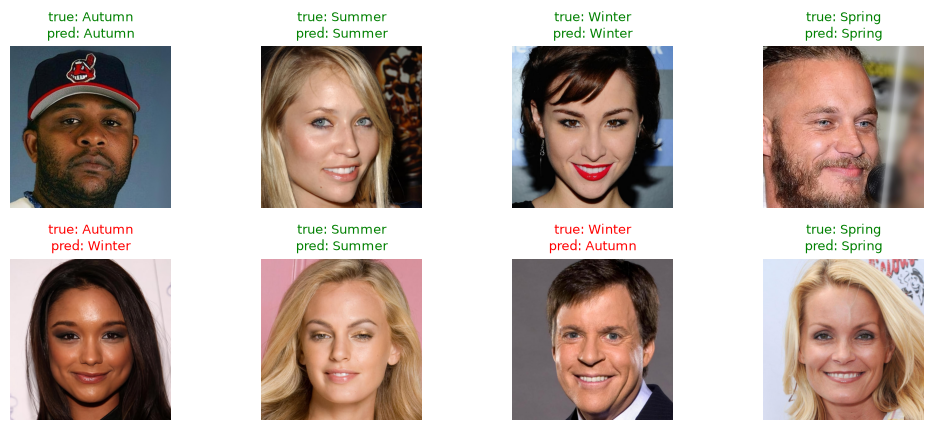

In [6]:
fig, axes = plt.subplots(
    N_PER_CLASS, len(config.CLASSES),
    figsize=(len(config.CLASSES) * 2.6, N_PER_CLASS * 2.2),
)

n_correct = 0
with torch.no_grad():
    for col_i, cls in enumerate(config.CLASSES):
        for row_i, idx in enumerate(sample_indices[cls]):
            image_tensor, true_label = test_ds[idx]
            logits = model(image_tensor.unsqueeze(0).to(device))
            pred_class = config.CLASSES[logits.argmax(dim=1).item()]
            true_class = config.CLASSES[true_label.item()]
            correct = pred_class == true_class
            n_correct += correct

            row = test_ds.df.loc[idx]
            raw_image = Image.open(raw_root / row["path_rgb_original"]).convert("RGB")

            ax = axes[row_i, col_i]
            ax.imshow(raw_image)
            ax.axis("off")
            ax.set_title(
                f"true: {config.CLASS_DISPLAY_NAMES[true_class]}\n"
                f"pred: {config.CLASS_DISPLAY_NAMES[pred_class]}",
                fontsize=9, color="green" if correct else "red",
            )

            mark = "correct" if correct else "wrong"
            print(f"{row['path_processed']:55s} true={true_class:10s} pred={pred_class:10s} {mark}")

n_total = len(config.CLASSES) * N_PER_CLASS
print(f"\n{n_correct}/{n_total} correct on this sample ({100 * n_correct / n_total:.0f}%)")

plt.tight_layout()
plt.show()